# CoffeaCasa

coffea-casa is a facility that provides a pre-configured Dask cluster at `tls://localhost:8786`. The intended execution model is `DaskExecutor` — coffea distributes file reading across the cluster's workers.

In practice, using `DaskExecutor` with `coffea-workflow`'s split strategy is currently unreliable due to a hard dependency on the exact coffea version installed in the worker image. See `README.md` for a full description of the problem.

The example below uses `FuturesExecutor`, which runs locally on the notebook server using Python multiprocessing. It still requires proper `coffea` version and `coffea-workflow` to be installed locally.

In [1]:
import sys
sys.path.insert(0, "..")

from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, ExecutorConfig, render
from coffea_workflow import facilities
from analysis import get_fileset, run_analysis, plot_results

In [2]:
# run_analysis receives an executor at runtime — user shouldn't define it in the analysis code.
step_fileset = Step(name="Fileset", step_type=Fileset, builder=get_fileset)
step_analysis = Step(name="Analysis", step_type=Analysis, builder=run_analysis)
step_plotting = Step(name="Plotting", step_type=Plotting, builder=plot_results)

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

Step(name='Plotting', step_type=<class 'coffea_workflow.artifacts.Plotting'>, builder=<function plot_results at 0x7fcd4bf876a0>, builder_params=None, facility=None, executor_config=None)

Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7fcd4bf87100>
  [1] Analysis -> Analysis builder=<function run_analysis at 0x7fcd4bf87380>
  [2] Plotting -> Plotting builder=<function plot_results at 0x7fcd4bf876a0>
Edges:
  Fileset -> Analysis
  Analysis -> Plotting
Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7fcd4bf87100> and user parameters None
Extracted from cache: .cache_coffea_casa/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89
  -> materialized at .cache_coffea_casa/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89
Executing step 'Analysis' of type 'Analysis' with the user code <function run_analysis at 0x7fcd4bf87380> and user parameters None
Extracted from cache: .cache_coffea_casa/Chunking/0370682774a2c9d78692884505552121b77c8c7500cbef254193a9b2e8a478ba

Split strategy applied, starting independent processing of 10 fileset subsets...

----------------------

Output()

/home/cms-jovyan/coffea/src/coffea/processor/executor.py:1278: UserWarning: Performed attempt 1 out of 4
  warnings.warn(
/home/cms-jovyan/coffea/src/coffea/processor/executor.py:1278: UserWarning: Performed attempt 2 out of 4
  warnings.warn(
/home/cms-jovyan/coffea/src/coffea/processor/executor.py:1278: UserWarning: Performed attempt 3 out of 4
  warnings.warn(
/home/cms-jovyan/coffea/src/coffea/processor/executor.py:1278: UserWarning: Performed attempt 4 out of 4
  warnings.warn(


loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/src/coffea/processor/executor.py", line 1290, in automatic_retries
    raise e
  File "/home/cms-jovyan/coffea/src/coffea/processor/executor.py", line 1276, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/src/coffea/processor/executor.py", line 1360, in metadata_fetcher_root
    with uproot.open(
         ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/uproot/reading.py", line 144, in open
    file = ReadOnlyFile(
           ^^^^^^^^^^^^^
  File "/usr/local/lib/pytho

Failure caught!
------------------------------------
Processing fileset_chunk_1.json
Extracted from cache: .cache_coffea_casa/ChunkAnalysis/828b42b4a82b6117f8ef44a4fc1095a8da17eb420841eb85c5550765acd2b9d6
Successfully processed!
------------------------------------
Processing fileset_chunk_2.json
Extracted from cache: .cache_coffea_casa/ChunkAnalysis/62800d4d5f08853d40d2aa3c38168f39afed79f0659358f8a2568c3abca555d8
Successfully processed!
------------------------------------
Processing fileset_chunk_3.json


...

Successfully processed!
------------------------------------
Processing fileset_chunk_9.json


Output()

Output()

Successfully processed!
  -> materialized at .cache_coffea_casa/Analysis/af829d369589e92f54ed6fb97c33479dfb18a10803721c01befc641c6a8bc24f
Executing step 'Plotting' of type 'Plotting' with the user code <function plot_results at 0x7fcd4bf876a0> and user parameters None
  -> materialized at .cache_coffea_casa/Plotting/f11779c4df64250ab8c330aef9ce1d9ecc13707610b186497e16e6a72798239b

=== Run Summary ===
  ✓  Fileset                        Fileset
  !  Analysis                       Analysis             9/10 chunks OK
       FAILED fileset_chunk_0.json: Err(OSError('XRootD error: [FATAL] Invalid address'))
  ✓  Plotting                       Plotting



{'paths': {'Fileset': PosixPath('.cache_coffea_casa/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89'),
  'Analysis': PosixPath('.cache_coffea_casa/Analysis/af829d369589e92f54ed6fb97c33479dfb18a10803721c01befc641c6a8bc24f'),
  'Plotting': PosixPath('.cache_coffea_casa/Plotting/f11779c4df64250ab8c330aef9ce1d9ecc13707610b186497e16e6a72798239b')},
 'results': {'Fileset': {'SingleMu_0': {'files': {'root://eeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWW

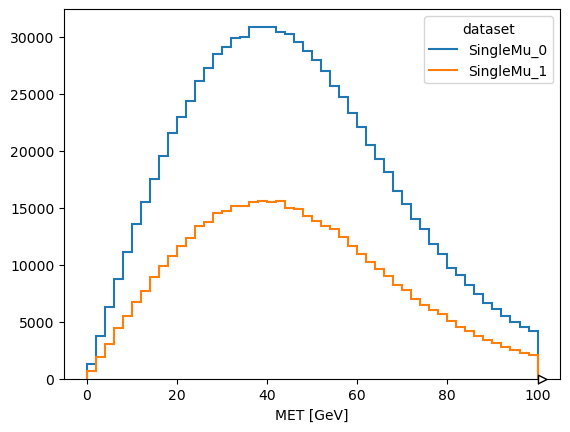

In [3]:
config = RunConfig(
    strategy="by_dataset",
    percentage=20,
    cache_dir=".cache_coffea_casa",
    facility=facilities.local,
    executor_config=ExecutorConfig(executor_type="FuturesExecutor", workers=4),
)

render(workflow, config)

### With Dask
TODO

Can not be demonstrated as for now. Requires coffea-workflow and local coffea version to be uploaded to dask workers, stops and disables processing whether it's PipInstall or whl.